# # Projeto de Análise de Dados - E-commerce Olist

Nesta etapa inicial, realizei o carregamento das bases de dados e a primeira inspeção para identificar a integridade dos dados e o volume de informações.

In [1]:
!pip install pandas seaborn matplotlib

In [2]:
import pandas as pd

In [3]:
# 1. Importação dos Datasets
#utilizando os arquivos CSV contendo informações de clientes, pedidos, itens, produtos e pagamentos para consolidar a análise.
caminho = "/home/nicoglic/Downloads/ecomerceDataSet/"

customers = pd.read_csv(caminho +'olist_customers_dataset.csv')
orders = pd.read_csv(caminho +'olist_orders_dataset.csv')
items = pd.read_csv(caminho +'olist_order_items_dataset.csv')
products = pd.read_csv(caminho +'olist_products_dataset.csv')
payments = pd.read_csv(caminho +'olist_order_payments_dataset.csv')

# 2. Diagnóstico de Dados Faltantes
#Abaixo, verificamos a presença de valores nulos e os tipos de dados de cada coluna. Note que as colunas de datas (`order_purchase_timestamp`, etc.) ainda estão como `object` e precisarão de conversão posterior.
#verificando quais colunas precisam de limpeza
print(orders.isnull().sum()) #mostra quantos nulos existem em cada coluna
print (orders.dtypes)

#Verificação de IDs Únicos
#Validando se o volume de IDs de pedidos corresponde ao esperado para garantir que não existam duplicatas inesperadas no dataframe principal.
total_pedidos = orders['order_id'].nunique()
print(f"Foram criados {total_pedidos} IDs de pedidos únicos.")


order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64
order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object
Foram criados 99441 IDs de pedidos únicos.


In [4]:
## 3. Filtragem e Limpeza de Nulos
#Para uma análise precisa do tempo de logística, focamos apenas nos pedidos que já foram efetivamente entregues ao destinatário final.
#Utilizamos o método `dropna` para remover registros sem data de entrega, garantindo a integridade dos cálculos de performance.

In [5]:

#4. Padronização de Tipos (Datetime)
#As colunas de data foram inicialmente lidas como texto (`object`). Abaixo, realizamos a conversão em massa para o formato `datetime`, o que permite realizar operações aritméticas com o tempo.
# Lista das colunas que são datas
colunas_datas = [
    'order_purchase_timestamp', 'order_approved_at', 
    'order_delivered_carrier_date', 'order_delivered_customer_date', 
    'order_estimated_delivery_date'
]

# Convertendo para o formato datetime
for coluna in colunas_datas:
    orders[coluna] = pd.to_datetime(orders[coluna])

# Verifique se mudou para datetime64
print(orders.dtypes)


order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object


In [6]:
# Criando a variável para calculo de tempo de entrega
orders_entregues = orders.dropna(subset=['order_delivered_customer_date']).copy()

# Calculando o tempo de entrega em dias
orders_entregues['tempo_entrega'] = (
    orders_entregues['order_delivered_customer_date'] - 
    orders_entregues['order_purchase_timestamp']
).dt.days

# Olhando o resultado
orders_entregues[['order_id', 'tempo_entrega']].head()




,order_id,tempo_entrega
0,e481f51cbdc54678b7cc49136f2d6af7,8
1,53cdb2fc8bc7dce0b6741e2150273451,13
2,47770eb9100c2d0c44946d9cf07ec65d,9
3,949d5b44dbf5de918fe9c16f97b45f8a,13
4,ad21c59c0840e6cb83a9ceb5573f8159,2


In [7]:
# Verificando os pedidos com entrega muito acima do normal
print(orders_entregues['tempo_entrega'].sort_values(ascending=False).head(10))

19590    209
55619    208
61610    195
70307    194
38509    194
89130    194
11399    191
81401    189
54480    188
68769    187
Name: tempo_entrega, dtype: int64


In [8]:
# Unindo pedidos entregues com os itens do pedido

#Criacao de tabela mestra
df_completo = pd.merge(orders_entregues, items, on='order_id', how='inner')

# Agora unindo com os produtos para saber a categoria
df_completo = pd.merge(df_completo, products, on='product_id', how='inner')

# 3. Conferindo o resultado
print(f"Total de linhas após a união: {len(df_completo)}")
df_completo[['order_id', 'product_category_name', 'price', 'tempo_entrega']].head()

Total de linhas após a união: 110196


,order_id,product_category_name,price,tempo_entrega
0,e481f51cbdc54678b7cc49136f2d6af7,utilidades_domesticas,29.99,8
1,53cdb2fc8bc7dce0b6741e2150273451,perfumaria,118.70,13
2,47770eb9100c2d0c44946d9cf07ec65d,automotivo,159.90,9
3,949d5b44dbf5de918fe9c16f97b45f8a,pet_shop,45.00,13
4,ad21c59c0840e6cb83a9ceb5573f8159,papelaria,19.90,2


In [9]:
# Criando coluna de Mês e Dia da Semana
df_completo['mes_compra'] = df_completo['order_purchase_timestamp'].dt.month
df_completo['dia_semana_compra'] = df_completo['order_purchase_timestamp'].dt.day_name()

In [10]:
# Qual a categoria que mais fatura na Olist?
faturamento_por_categoria = df_completo.groupby('product_category_name')['price'].sum().sort_values(ascending = False)
print(faturamento_por_categoria.head(10))

product_category_name
beleza_saude              1233211.61
relogios_presentes        1165898.98
cama_mesa_banho           1023434.76
esporte_lazer              954695.05
informatica_acessorios     888613.62
moveis_decoracao           711927.69
utilidades_domesticas      615628.69
cool_stuff                 610204.10
automotivo                 578849.35
brinquedos                 471197.48
Name: price, dtype: float64


In [11]:
# Contando quantas linhas existem para cada mês
movimentacao_mensal = df_completo['mes_compra'].value_counts().sort_index()

print("Quantidade de pedidos por mês:")
print(movimentacao_mensal)

Quantidade de pedidos por mês:
mes_compra
1      8950
2      9377
3     10914
4     10396
5     11813
6     10496
7     11376
8     11939
9      4740
10     5533
11     8474
12     6188
Name: count, dtype: int64


In [12]:
# Contando pedidos por dia da semana
vendas_por_dia = df_completo['dia_semana_compra'].value_counts()

# Reordenando para seguir a ordem lógica da semana (opcional, mas fica mais bonito)
dias_ordem = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
vendas_por_dia = vendas_por_dia.reindex(dias_ordem)

print("Volume de vendas por dia da semana:")
print(vendas_por_dia)

Volume de vendas por dia da semana:
dia_semana_compra
Monday       17975
Tuesday      17857
Wednesday    17217
Thursday     16433
Friday       15698
Saturday     11886
Sunday       13130
Name: count, dtype: int64


In [13]:
# Calculando a correlação entre frete e tempo de entrega
correlacao = df_completo[['freight_value', 'tempo_entrega']].corr()

print("Matriz de Correlação (Frete vs Tempo):")
print(correlacao)

Matriz de Correlação (Frete vs Tempo):
               freight_value  tempo_entrega
freight_value       1.000000       0.214631
tempo_entrega       0.214631       1.000000


In [14]:
#criacao de varivel para trabalhar as tabelas com principais categorias
top_categorias = df_completo.groupby('product_category_name')['price'].sum().sort_values(ascending=False).head(5)

print('As 5 categorias com mais vendas')
print (top_categorias)

As 5 categorias com mais vendas
product_category_name
beleza_saude              1233211.61
relogios_presentes        1165898.98
cama_mesa_banho           1023434.76
esporte_lazer              954695.05
informatica_acessorios     888613.62
Name: price, dtype: float64


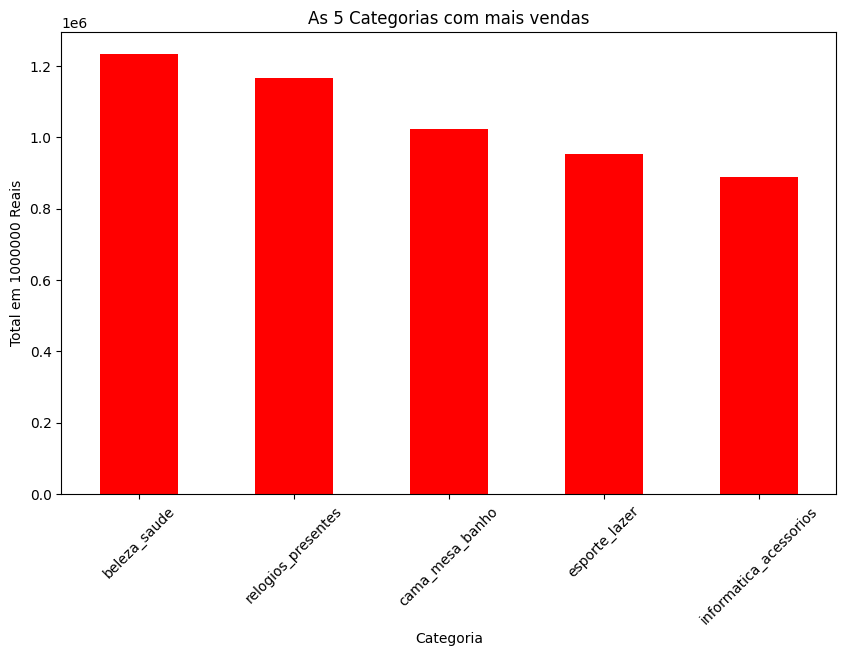

In [15]:
import matplotlib.pyplot as plt

#criando um grafico simples de barras para mostrar categorias com mais vendas
top_categorias.plot(kind = 'bar', color = 'red', figsize= (10,6))
plt.title('As 5 Categorias com mais vendas')
plt.ylabel('Total em 1000000 Reais')
plt.xlabel('Categoria')
plt.xticks(rotation=45)
plt.show()

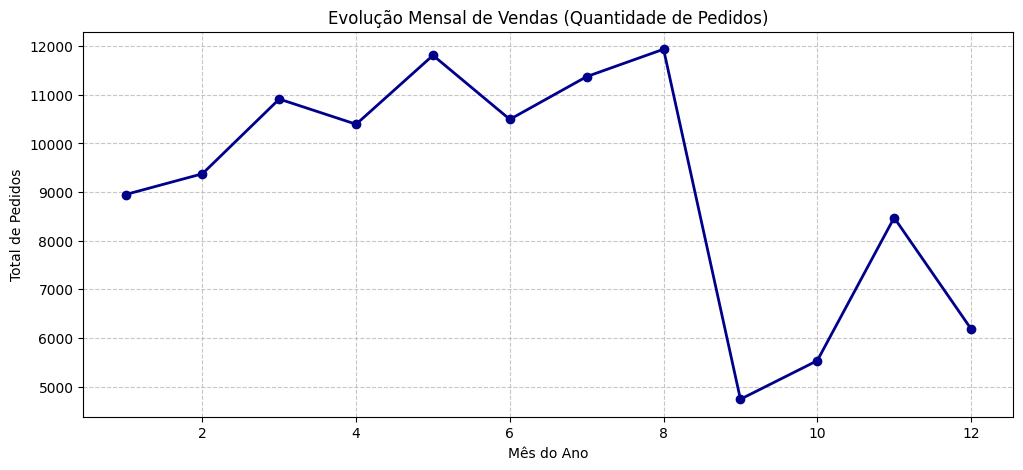

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Agrupando por mês e contando pedidos
vendas_mensais = df_completo.groupby('mes_compra').size()

plt.figure(figsize=(12, 5))
vendas_mensais.plot(kind='line', marker='o', color='darkblue', linewidth=2)
plt.title('Evolução Mensal de Vendas (Quantidade de Pedidos)')
plt.xlabel('Mês do Ano')
plt.ylabel('Total de Pedidos')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [17]:
df_completo.corr(numeric_only=True)


,tempo_entrega,order_item_id,price,freight_value,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,mes_compra
tempo_entrega,1.000000,-0.015729,0.062290,0.214631,-0.003207,0.005280,-0.026778,0.085610,0.068717,0.066871,0.039302,-0.056692
order_item_id,-0.015729,1.000000,-0.060565,-0.028975,-0.021809,-0.013713,-0.055467,-0.002891,0.006023,0.029789,-0.010407,-0.001250
price,0.062290,-0.060565,1.000000,0.412718,0.018662,0.198258,0.052179,0.338371,0.143947,0.222163,0.172997,0.002033
freight_value,0.214631,-0.028975,0.412718,1.000000,0.025575,0.094895,0.022389,0.610280,0.306316,0.389510,0.322012,0.005738
product_name_lenght,-0.003207,-0.021809,0.018662,0.025575,1.000000,0.090706,0.145713,0.023879,0.063526,-0.027793,0.065818,0.013495
product_description_lenght,0.005280,-0.013713,0.198258,0.094895,0.090706,1.000000,0.118443,0.059305,0.006082,0.073054,-0.068994,-0.014844
product_photos_qty,-0.026778,-0.055467,0.052179,0.022389,0.145713,0.118443,1.000000,0.023115,0.048433,-0.033603,0.011111,0.010983
product_weight_g,0.085610,-0.002891,0.338371,0.610280,0.023879,0.059305,0.023115,1.000000,0.460140,0.584100,0.507126,-0.008677
product_length_cm,0.068717,0.006023,0.143947,0.306316,0.063526,0.006082,0.048433,0.460140,1.000000,0.191631,0.532818,-0.003720
product_height_cm,0.066871,0.029789,0.222163,0.389510,-0.027793,0.073054,-0.033603,0.584100,0.191631,1.000000,0.280048,0.013515


In [18]:
#notei uma correlação moderada entre o preço do produto e o frete, sugerindo que itens mais caros podem ter custos de envio
#maiores, possivelmente devido a seguros ou dimensões maiores.

#tambem, naturalmente, fretes mais caros sugerem um tempo de entrega maior

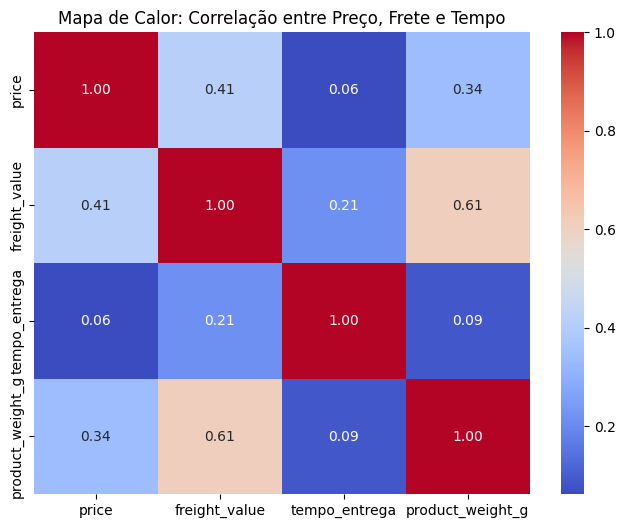

In [19]:
# Selecionando apenas colunas numéricas para o mapa de calor
colunas_analise = ['price', 'freight_value', 'tempo_entrega', 'product_weight_g']
matriz_correlacao = df_completo[colunas_analise].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Calor: Correlação entre Preço, Frete e Tempo')
plt.show()